## Import the necessary functions 

In [1]:
# Import the necessary functions

# Personalised functions created for this NN application
from NEMO_NN_functions import *
# To convert from lat lon, to x y
from pyproj import Transformer
# To extract just the bedmachine mask within the NEMO 1 degree grid 
from shapely.geometry import Polygon
from shapely.vectorized import contains
# To extract neighbouring cells
from scipy.ndimage import binary_dilation 
# To plot figures 
import matplotlib.pyplot as plt

# To create the ocean profile 
from scipy.spatial import cKDTree

## Set variables 

In [20]:
# The target grid mask 
#filepath_mask = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geometric_masks.nc'
#filepath_mask = '/bettik/ockendeh/NEMO_simulations/OPM026_geometric_masks_newbasins.nc'
filepath_mask = '/bettik/ockendeh/NEMO_simulations/test_mask_geoms/geometric_masks_NEMO025_BMach2_99pc.nc'
# The target grid geometry
#filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geom_vars.nc'
#filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/OPM026_geom_vars_frac1.nc'
filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/test_mask_geoms/geom_vars_NEMO025_BMach2_99pc.nc'

join_ice_shelves = False

In [21]:
masks, basins_merged, geoms = load_geom_files(filepath_geomvars, 
                                              filepath_mask, 
                                              join_ice_shelves = join_ice_shelves)
if 'y_grid_T' in basins_merged.dims:
    basins_merged = basins_merged.rename({"y_grid_T": "y", "x_grid_T": "x"}).astype(int)
    
basins_NEMO = masks.basins_NEMO.values
if join_ice_shelves == True:
    # Dotson and Crosson?
    #basins_NEMO[basins_NEMO == 101] = 129
    # Abbot Ice Shelf
    basins_NEMO[basins_NEMO == 109] = 143
    # George VI
    basins_NEMO[basins_NEMO == 112] = 125
    # Lambert 
    basins_NEMO[basins_NEMO == 20] = 103
basin_nos = np.arange(1,156, dtype = 'float32')
basin_nos = np.unique(basins_NEMO)

You have loaded: /bettik/ockendeh/NEMO_simulations/test_mask_geoms/geom_vars_NEMO025_BMach2_99pc.nc
You have loaded: /bettik/ockendeh/NEMO_simulations/test_mask_geoms/geometric_masks_NEMO025_BMach2_99pc.nc


### Create a list of the cells where it is okay to extract ocean profiles 

In [22]:
colors = []
for kk in range(len(basin_nos)):
    if np.mod(kk, 3) == 0:
        colors.append('k')
    elif np.mod(kk, 3) == 1:
        colors.append('lightblue')
    elif np.mod(kk, 3) == 2:
        colors.append('tomato')
colors[73] = 'k'
colors[19] = 'tomato'
colors[29] = 'k'
colors[27] = 'tomato'
colors[28] = 'k'
colors[45] = 'lightblue'
colors[57] = 'tomato'
colors[64] = 'tomato'
colors[48] = 'tomato'
colors[101] = 'lightblue'
colors[49] = 'k'
colors[52] = 'tomato'
colors[125] = 'k'
colors[6] = 'tomato'
colors[12] = 'lightblue'
colors[119] = 'k'
colors[21] = 'lightblue'
colors[108] = 'tomato'
colors[115] = 'k'
colors[90] = 'lightblue'
colors[35] = 'tomato'
colors[30] = 'lightblue'
colors[85] = 'tomato'
colors[31] = 'tomato'
colors[80] = 'k'
colors[47] = 'k'
colors[78] = 'tomato'

alter_coords = []
for kk in range(len(basin_nos)):
    alter_coords.append((0.0,0.0))#.astype(float32))

alter_coords[119] = (-2.5, -1)
alter_coords[18] = (0, 1)
alter_coords[77] = (-2, 0)
alter_coords[94] = (-2,-1.5)
alter_coords[32] = (-2.5,1)
alter_coords[28] = (-1,0)
alter_coords[2] = (1.8,-1.2)
alter_coords[6] = (-0.5,-0.6)
alter_coords[4] = (-0.2,-0.1)
alter_coords[1] = (1,-0.2)
alter_coords[14] = (0.3,-0.9)
alter_coords[15] = (-2,-1.5)
alter_coords[3] = (0,0.3)
alter_coords[21] = (-0.8,1.5)
alter_coords[19] = (-1.8,-1.2)
alter_coords[25] = (-3.5,0)
alter_coords[37] = (-2,1)
alter_coords[38] = (-0.3,0)
alter_coords[41] = (-1,2)
alter_coords[44] = (-0.3,2)
alter_coords[42] = (-0.5,0)
alter_coords[35] = (-2,1)
alter_coords[43] = (-0.5,0)
alter_coords[61] = (0.5,1.5)
alter_coords[126] = (-0.5,0)
alter_coords[121] = (-1.3,1)
alter_coords[122] = (-0.7,1.8)
alter_coords[93] = (0,1.3)
alter_coords[57] = (0.8, 0.8)
alter_coords[58] = (1,0.3)
alter_coords[55] = (0,1.6)
alter_coords[59] = (1.0,0.2)
alter_coords[60] = (1.0,0.1)
alter_coords[56] = (-1.3,0.4)
alter_coords[127] = (-0.5,-0.5)
alter_coords[47] = (1,0.7)
alter_coords[46] = (1, 0.8)
alter_coords[80] = (-1,0)
alter_coords[85] = (-1,0.5)

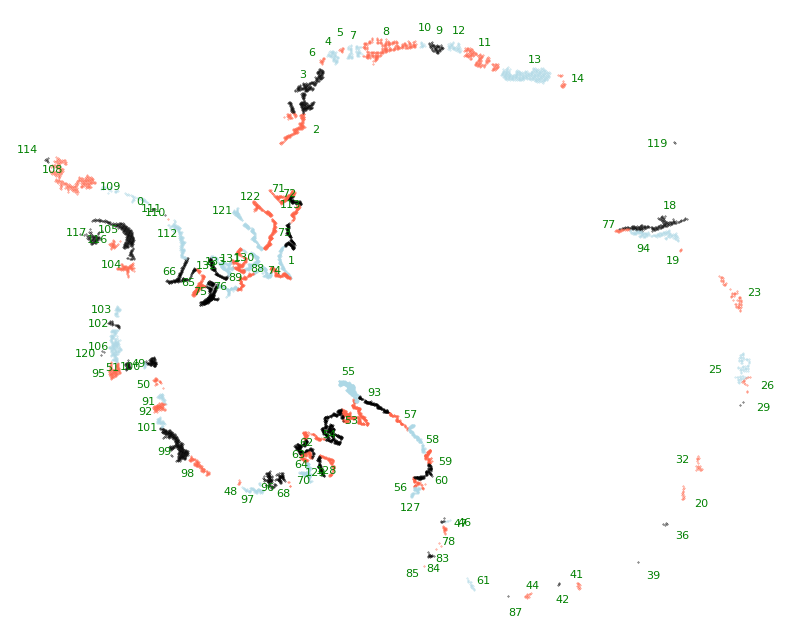

In [24]:
plot_basin_nos_map = True
if plot_basin_nos_map == True:
    fig, ax = plt.subplots(1,1, figsize = (10,8))
    for kk in range(len(basin_nos)):
    #for kk in (0,1,2,3):
    #for kk in (77, 18):
        i = basin_nos[kk]
        mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
        # Extract these points 
        idx = np.where(mask_basin_cavs == 1)
        lat_cavs = masks.lat.values[idx]
        lon_cavs = masks.lon.values[idx]
        # Transform to x and y
        transformer = Transformer.from_crs("epsg:4326","epsg:3031")
        x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
        if len(x_cavs) > 0:
            plt.scatter(x_cavs, y_cavs, s = 0.1, color = colors[kk])
            plt.annotate(int(i), xy = (0,0), xytext = (np.mean(x_cavs)*1.06+alter_coords[kk][0]*1e5, \
                                                   np.mean(y_cavs)*1.06+alter_coords[kk][1]*1e5), \
                         fontsize = 8, ha = 'center', va = 'center', c = 'green')#colors[kk])
    ax.axis('off');

In [6]:
# The target grid mask 
filepath_mask_b3 = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geometric_masks.nc'
filepath_mask = '/bettik/ockendeh/NEMO_simulations/OPM026_geometric_masks_newbasins.nc'
# The target grid geometry
filepath_geomvars_b3 = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geom_vars.nc'
filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/OPM026_geom_vars_frac1.nc'

# Open these masks
mask_b3 = xr.open_dataset(filepath_mask_b3)
mask_b2 = xr.open_dataset(filepath_mask)
geoms_b3 = xr.open_dataset(filepath_geomvars_b3)
geoms_b2 = xr.open_dataset(filepath_geomvars)

In [7]:
area_both = np.sum(((mask_b3.closed_cavities_nan == 1) & (mask_b2.closed_cavities_nan == 1)) * geoms_b3.areas)/1e6
area_new = np.sum(((mask_b3.closed_cavities_nan == 1) & (mask_b2.closed_cavities == 0)) * geoms_b3.areas * geoms_b3.fraction)/1e6
area_old = np.sum(((mask_b3.closed_cavities == 0) & (mask_b2.closed_cavities == 1)) * geoms_b3.areas)/1e6
print(area_both, area_new, area_old)
np.sum(mask_b3.closed_cavities_nan * geoms_b3.areas * geoms_b3.fraction)/1e6, \
np.sum(mask_b2.closed_cavities_nan * geoms_b2.areas)/1e6

<xarray.DataArray ()> Size: 8B
array(513058.51148885) <xarray.DataArray ()> Size: 8B
array(168387.10931694) <xarray.DataArray ()> Size: 8B
array(39999.67600277)


(<xarray.DataArray ()> Size: 8B
 array(619088.29835147),
 <xarray.DataArray ()> Size: 8B
 array(553058.18749162))

(np.float64(-2911435.4631237397),
 np.float64(2997647.0234558494),
 np.float64(-2725699.31109401),
 np.float64(2564840.438776828))

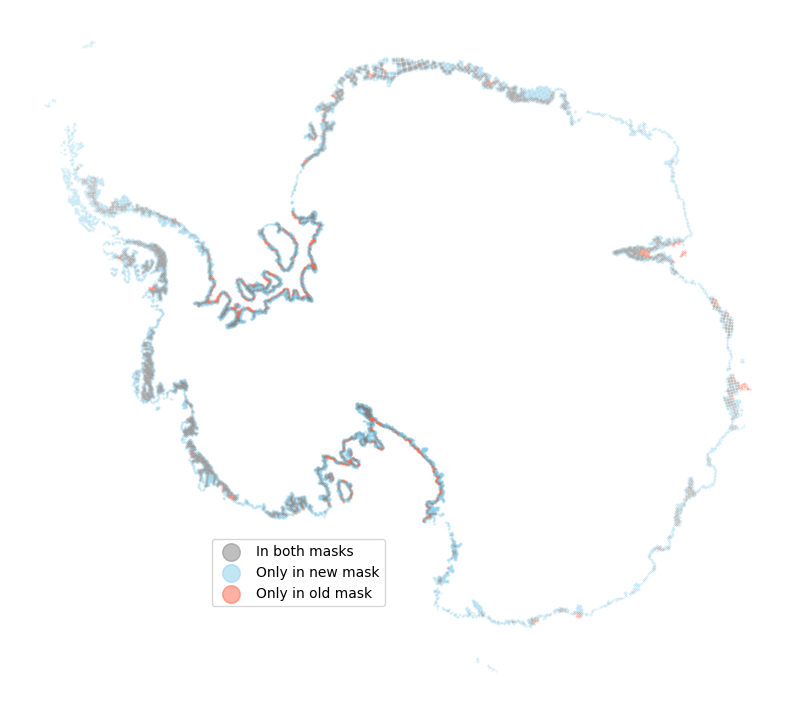

In [8]:
mask_b3


lat_cavs = masks.lat.values[(mask_b3.closed_cavities_nan == 1) & (mask_b2.closed_cavities_nan == 1)]
lon_cavs = masks.lon.values[(mask_b3.closed_cavities_nan == 1) & (mask_b2.closed_cavities_nan == 1)]
transformer = Transformer.from_crs("epsg:4326","epsg:3031")
x_mask, y_mask = transformer.transform(lat_cavs, lon_cavs)

lat_cavs2 = masks.lat.values[(mask_b3.closed_cavities_nan == 1) & (mask_b2.closed_cavities == 0)]
lon_cavs2 = masks.lon.values[(mask_b3.closed_cavities_nan == 1) & (mask_b2.closed_cavities == 0)]
transformer = Transformer.from_crs("epsg:4326","epsg:3031")
x_mask2, y_mask2 = transformer.transform(lat_cavs2, lon_cavs2)

lat_cavs3 = masks.lat.values[(mask_b3.closed_cavities == 0) & (mask_b2.closed_cavities_nan == 1)]
lon_cavs3 = masks.lon.values[(mask_b3.closed_cavities == 0) & (mask_b2.closed_cavities_nan == 1)]
transformer = Transformer.from_crs("epsg:4326","epsg:3031")
x_mask3, y_mask3 = transformer.transform(lat_cavs3, lon_cavs3)

fig, ax = plt.subplots(1,1, figsize = (10,10))
ax.scatter(x_mask, y_mask, s = 0.1, c = 'grey', alpha = 0.5, label = 'In both masks')
ax.scatter(x_mask2, y_mask2, s = 0.1, c = 'skyblue', alpha = 0.5, label = 'Only in new mask')
ax.scatter(x_mask3, y_mask3, s = 0.1, c = 'tomato', alpha = 0.5, label = 'Only in old mask')
ax.set_aspect(1)
ax.legend(loc = (0.26,0.14), markerscale = 40)
ax.axis('off')

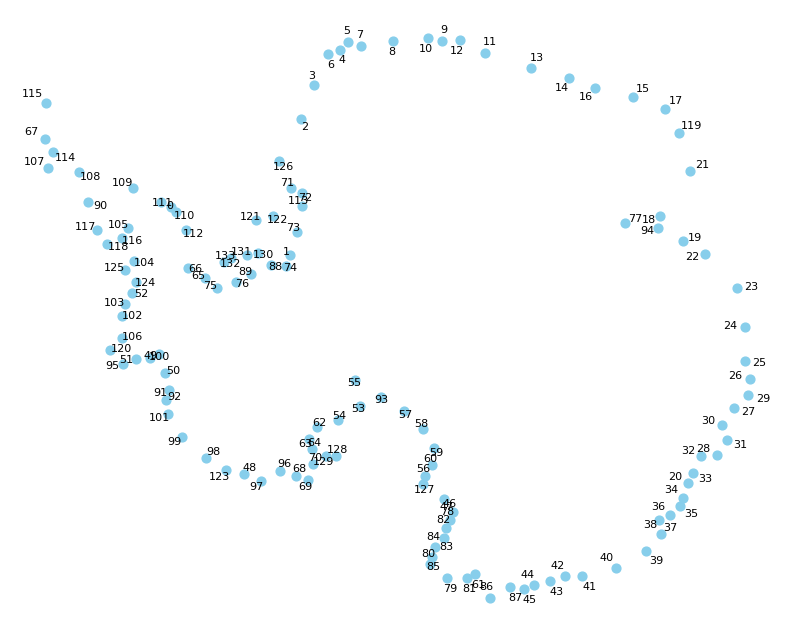

In [9]:
plot_basin_nos_map = True
if plot_basin_nos_map == True:
    fig, ax = plt.subplots(1,1, figsize = (10,8))
    for kk in range(len(basin_nos)):
        i = basin_nos[kk]
        mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
        # Extract these points 
        idx = np.where(mask_basin_cavs == 1)
        lat_cavs = masks.lat.values[idx]
        lon_cavs = masks.lon.values[idx]
        # Transform to x and y
        transformer = Transformer.from_crs("epsg:4326","epsg:3031")
        x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
        if len(x_cavs) > 0:
            plt.scatter(np.mean(x_cavs), np.mean(y_cavs), s = 40, c = 'skyblue')
        if np.mod(i,2) == 1: 
            plt.annotate(int(i), xy = (0,0), xytext = (np.mean(x_cavs)*1.04, np.mean(y_cavs)*1.04), fontsize = 8, ha = 'center', va = 'center')
        else:
          plt.annotate(int(i), xy = (0,0), xytext = (np.mean(x_cavs)*0.96, np.mean(y_cavs)*0.96), fontsize = 8, ha = 'center', va = 'center')  
    ax.axis('off');